In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
file_path = '/home/giacomo/Thesis/Entropy-conjecture/Precession_Analysis/bbh_simulations_archive/BBH_q=0.30_chi1=0.60_chi2=0.70_th1=45_th2=45_dphi=90.csv'

In [28]:
df = pd.read_csv(file_path, comment='#')

q = 0.2
m1 = 1 / (1 + q)  
m2 = q / (1 + q)
chi1 = 0.8
chi2 = 0.2
eta = m1 * m2

S1 = chi1 * m1**2
S2 = chi2 * m2**2

a = df['separation_M']
th1 = df['theta1_rad']
th2 = df['theta2_rad']
dphi = df['deltaphi_rad']

E_bin = - (m1 * m2) / (2 * a)
M_tot = (m1 + m2) - np.abs(E_bin)

L_0PN = eta * np.sqrt(a)
L_dot_S1 = L_0PN * S1 * np.cos(th1)
L_dot_S2 = L_0PN * S2 * np.cos(th2)
cos_gamma = (np.sin(th1) * np.sin(th2) * np.cos(dphi) + 
             np.cos(th1) * np.cos(th2))
S1_dot_S2 = S1 * S2 * cos_gamma
J_mag = np.sqrt(L_0PN**2 + S1**2 + S2**2 + 2*L_dot_S1 + 2*L_dot_S2 + 2*S1_dot_S2)

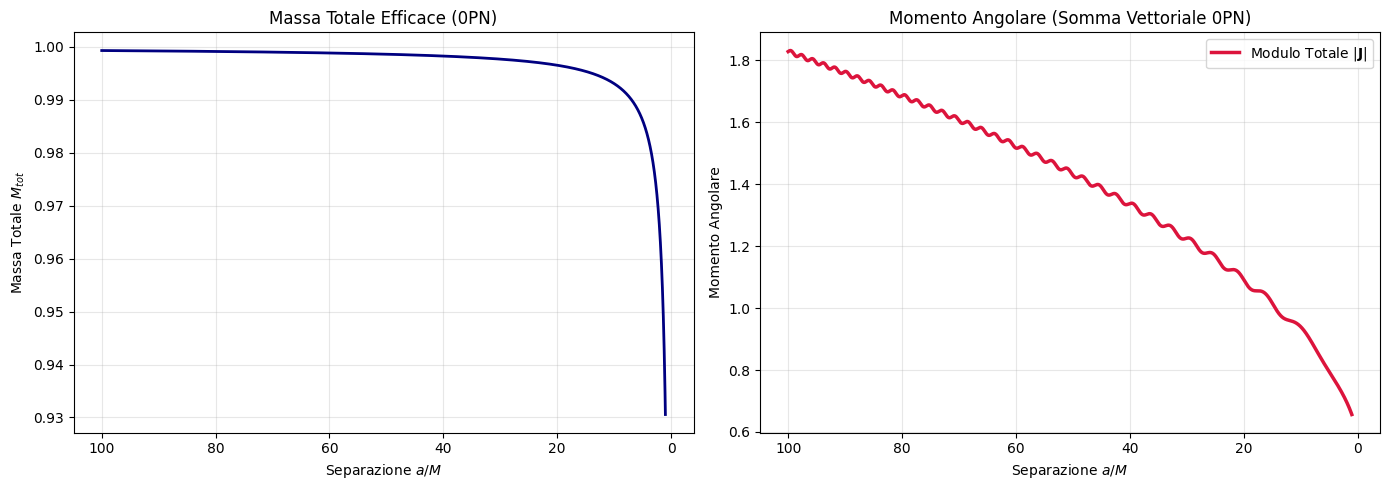

In [29]:
# 4. Visualizzazione
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Massa Totale
ax[0].plot(a, M_tot, color='navy', lw=2, label='$M_{tot}$')
ax[0].set_xlabel('Separazione $a/M$')
ax[0].set_ylabel('Massa Totale $M_{tot}$')
ax[0].set_title('Massa Totale Efficace (0PN)')
ax[0].grid(True, alpha=0.3)
ax[0].invert_xaxis()

# Plot Momento Angolare Totale
ax[1].plot(a, J_mag, color='crimson', lw=2.5, label=r'Modulo Totale $|\mathbf{J}|$')
ax[1].set_xlabel('Separazione $a/M$')
ax[1].set_ylabel('Momento Angolare')
ax[1].set_title('Momento Angolare (Somma Vettoriale 0PN)')
ax[1].grid(True, alpha=0.3)
ax[1].legend()
ax[1].invert_xaxis()

plt.tight_layout()
plt.show()

In [18]:
def entropy (M,J) :
    arg_sqrt = M**2 - ((J**2)/(M**2))

    if arg_sqrt < 0 :
        return np.nan
    else :
        return 2 * np.pi * M * (M + np.sqrt(arg_sqrt))

In [30]:
ENT = []
for m,j in zip (M_tot,J_mag) :
    ent = entropy (m,j)
    ENT.append(ent)

print ( len(ENT))


10000


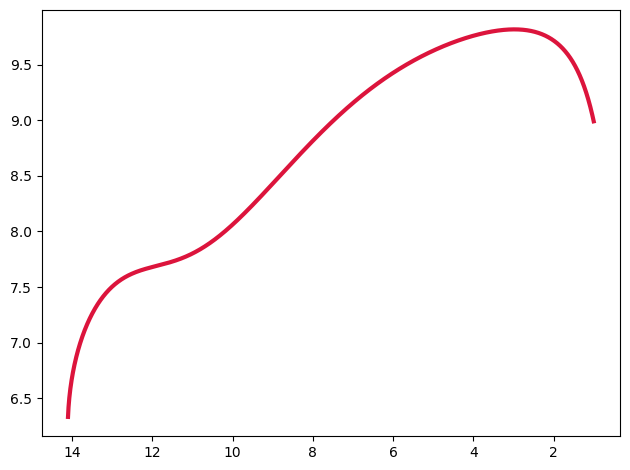

In [31]:
plt.plot(a, ENT, color='crimson', lw=3, label=r'Entropia Dinamica $S(M_{\mathrm{tot}}, |\mathbf{J}|)$')


plt.gca().invert_xaxis()

plt.tight_layout()
plt.show()

<>:79: SyntaxWarning: invalid escape sequence '\g'
<>:79: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_20884/2161311673.py:79: SyntaxWarning: invalid escape sequence '\g'
  plt.plot(a, S_sim, color='crimson', lw=3.5, label='Dati Simulazione (a/M $\geq$ 10)')


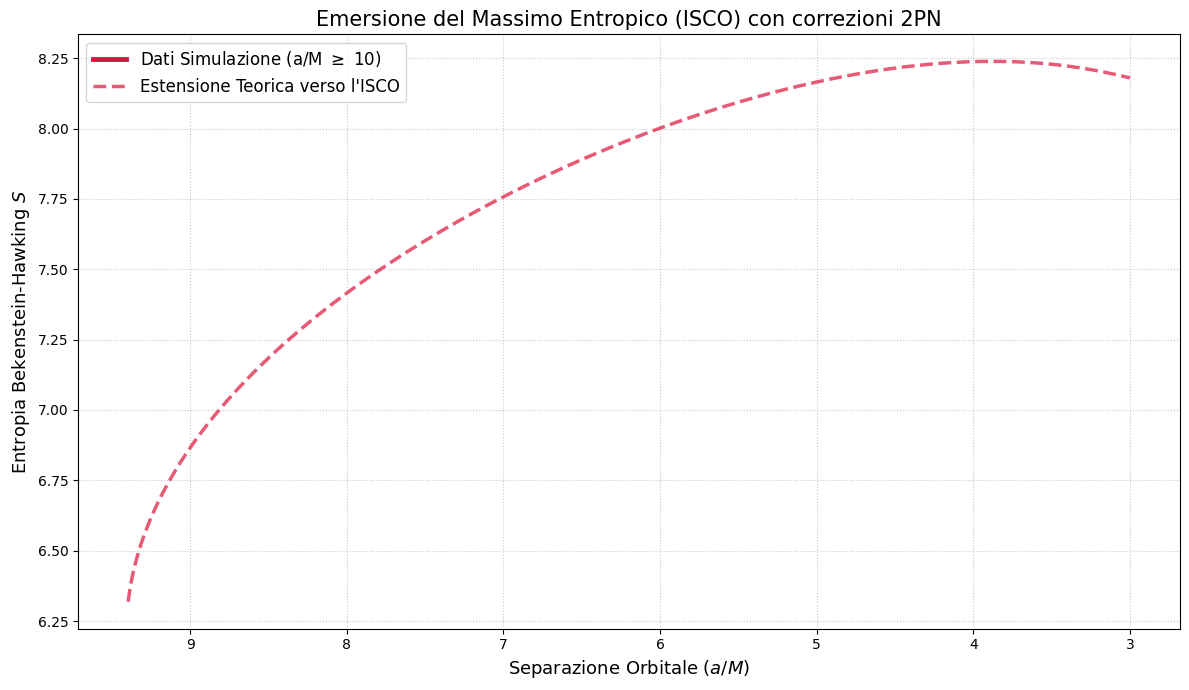

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Caricamento dati
file_path = '/home/giacomo/Thesis/Entropy-conjecture/Precession_Analysis/bbh_simulations_archive/BBH_q=0.20_chi1=0.80_chi2=0.20_th1=45_th2=45_dphi=90.csv'
df = pd.read_csv(file_path, comment='#')

# Parametri
q = 0.2
m1 = 1 / (1 + q)  
m2 = q / (1 + q)
chi1 = 0.8
chi2 = 0.2
eta = m1 * m2

S1_mag = chi1 * m1**2
S2_mag = chi2 * m2**2

# Dati simulazione
a = df['separation_M']
th1 = df['theta1_rad']
th2 = df['theta2_rad']
dphi = df['deltaphi_rad']

# ==========================================
# FUNZIONE PER IL CALCOLO DELL'ENTROPIA A 2PN
# ==========================================
def calc_entropy_2PN(a_val, th1_val, th2_val, dphi_val):
    x = 1.0 / a_val # Parametro PN
    
    # 1. Energia di Legame 2PN
    c1_E = -0.75 - eta/12.0
    c2_E = -3.375 + (19.0/8.0)*eta - (eta**2)/24.0
    E_bin_2PN = - (eta / (2 * a_val)) * (1 + c1_E * x + c2_E * (x**2))
    M_tot_2PN = (m1 + m2) + E_bin_2PN

    # 2. Momento Angolare Orbitale 2PN
    c1_L = 1.5 + eta/6.0
    c2_L = 3.375 - (19.0/8.0)*eta + (eta**2)/24.0
    L_2PN = eta * np.sqrt(a_val) * (1 + c1_L * x + c2_L * (x**2))
    
    # 3. Somma Vettoriale (Assumendo L lungo Z)
    L_dot_S1 = L_2PN * S1_mag * np.cos(th1_val)
    L_dot_S2 = L_2PN * S2_mag * np.cos(th2_val)
    cos_gamma = (np.sin(th1_val) * np.sin(th2_val) * np.cos(dphi_val) + 
                 np.cos(th1_val) * np.cos(th2_val))
    S1_dot_S2 = S1_mag * S2_mag * cos_gamma
    
    J_mag = np.sqrt(L_2PN**2 + S1_mag**2 + S2_mag**2 + 2*L_dot_S1 + 2*L_dot_S2 + 2*S1_dot_S2)
    
    # 4. Entropia Dinamica
    arg_radice = M_tot_2PN**4 - J_mag**2
    S_dyn = np.where(arg_radice >= 0, 
                     2 * np.pi * (M_tot_2PN**2 + np.sqrt(np.maximum(arg_radice, 0))), 
                     np.nan)
    return S_dyn

# Calcolo sui dati della simulazione (fino ad a=10)
S_sim = calc_entropy_2PN(a, th1, th2, dphi)

# ==========================================
# ESTENSIONE ANALITICA FINO ALL'ISCO (a=3)
# ==========================================
# Simuliamo il proseguimento fissando gli angoli finali della simulazione
a_ext = np.linspace(a.iloc[-1], 3.0, 500)
th1_ext = np.full_like(a_ext, th1.iloc[-1])
th2_ext = np.full_like(a_ext, th2.iloc[-1])
dphi_ext = np.full_like(a_ext, dphi.iloc[-1])

S_ext = calc_entropy_2PN(a_ext, th1_ext, th2_ext, dphi_ext)

# ==========================================
# VISUALIZZAZIONE
# ==========================================
plt.figure(figsize=(12, 7))

# Dati Reali della simulazione
plt.plot(a, S_sim, color='crimson', lw=3.5, label='Dati Simulazione (a/M $\geq$ 10)')

# Estensione Analitica
plt.plot(a_ext, S_ext, color='crimson', lw=2.5, linestyle='--', alpha=0.7, 
         label='Estensione Teorica verso l\'ISCO')

# Estetica
plt.xlabel(r'Separazione Orbitale ($a/M$)', fontsize=13)
plt.ylabel(r'Entropia Bekenstein-Hawking $S$', fontsize=13)
plt.title('Emersione del Massimo Entropico (ISCO) con correzioni 2PN', fontsize=15)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)
plt.gca().invert_xaxis()

plt.tight_layout()
plt.show()